#Model 1: Standard Model - EfficientNetB2 with Transfer Learning

In [ ]:
# Load CUB-200-2011 Dataset into Compute instance storage

from google.colab import drive
drive.mount('/content/drive')

!cp /content/drive/MyDrive/datasets/bird_CUB_200_2011.zip /content/
!unzip -q /content/bird_CUB_200_2011.zip -d /content/

Mounted at /content/drive


In [ ]:
# Load dataset and metadata, Train/Test Split and Bounding Boxes

import os
import pandas as pd

DATA_ROOT = "/content/CUB_200_2011"
IMAGES_DIR = os.path.join(DATA_ROOT, "images")

# Load metadata files
images_txt = pd.read_csv(os.path.join(DATA_ROOT, "images.txt"),
                         sep=r"\s+", header=None, names=["image_id", "image_path"])

split_txt = pd.read_csv(os.path.join(DATA_ROOT, "train_test_split.txt"),
                        sep=r"\s+", header=None, names=["image_id", "is_train"])

labels_txt = pd.read_csv(os.path.join(DATA_ROOT, "image_class_labels.txt"),
                         sep=r"\s+", header=None, names=["image_id", "class_id"])

classes_txt = pd.read_csv(os.path.join(DATA_ROOT, "classes.txt"),
                          sep=r"\s+", header=None, names=["class_id", "class_name"])

bbox = pd.read_csv(os.path.join(DATA_ROOT, "bounding_boxes.txt"),
                   sep=r"\s+", header=None, names=["image_id","x","y","w","h"])

# Merge into one table
df = images_txt.merge(split_txt, on="image_id").merge(labels_txt, on="image_id").merge(classes_txt, on="class_id").merge(bbox, on="image_id")

# Convert to absolute file paths
df["filepath"] = df["image_path"].apply(lambda p: os.path.join(IMAGES_DIR, p))
assert df["filepath"].apply(os.path.exists).all(), "Some image paths don't exist. Check DATA_ROOT."

print("Total images:", len(df))
print("Train images:", (df["is_train"] == 1).sum())
print("Test images:", (df["is_train"] == 0).sum())
print("Num classes:", df["class_id"].nunique())
df.head()

Total images: 11788
Train images: 5994
Test images: 5794
Num classes: 200


,image_id,image_path,is_train,class_id,class_name,x,y,w,h,filepath
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,0,1,001.Black_footed_Albatross,60.0,27.0,325.0,304.0,/content/CUB_200_2011/images/001.Black_footed_...
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,001.Black_footed_Albatross,139.0,30.0,153.0,264.0,/content/CUB_200_2011/images/001.Black_footed_...
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,0,1,001.Black_footed_Albatross,14.0,112.0,388.0,186.0,/content/CUB_200_2011/images/001.Black_footed_...
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,001.Black_footed_Albatross,112.0,90.0,255.0,242.0,/content/CUB_200_2011/images/001.Black_footed_...
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,1,1,001.Black_footed_Albatross,70.0,50.0,134.0,303.0,/content/CUB_200_2011/images/001.Black_footed_...


In [ ]:
# Check dataset integrity

print("Rows:", len(df))
print("Unique image_id:", df["image_id"].nunique())
print("Any missing bboxes?", df[["x","y","w","h"]].isna().any().to_dict())
print("Min class_id:", df["class_id"].min(), "Max class_id:", df["class_id"].max())
print("Train:", (df["is_train"]==1).sum(), "Test:", (df["is_train"]==0).sum())

Rows: 11788
Unique image_id: 11788
Any missing bboxes? {'x': False, 'y': False, 'w': False, 'h': False}
Min class_id: 1 Max class_id: 200
Train: 5994 Test: 5794


In [ ]:
# Stratified Train/Validation Split

import numpy as np
from sklearn.model_selection import train_test_split

SEED = 42

train_full = df[df["is_train"] == 1].copy()
test_df = df[df["is_train"] == 0].copy()

train_df2, val_df = train_test_split(
    train_full,
    test_size=0.10,
    stratify=train_full["class_id"],
    random_state=SEED
)

print("Train:", len(train_df2), "Val:", len(val_df), "Test:", len(test_df))
print("BBox columns present?", all(c in train_df2.columns for c in ["x","y","w","h"]))

Train: 5394 Val: 600 Test: 5794
BBox columns present? True


In [ ]:
# Build TensorFlow Data Pipeline (BBox Crop, Augmentation, Preprocessing)

import tensorflow as tf
import numpy as np

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

IMG_SIZE = 260
BATCH_SIZE = 16
NUM_CLASSES = 200

tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

# EfficientNet preprocessing
preprocess = tf.keras.applications.efficientnet.preprocess_input

# Augmenter
augmenter = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
], name="augmenter")

AUTOTUNE = tf.data.AUTOTUNE

def load_image_with_bbox(path, label, x, y, w, h, pad=0.15):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_bytes, channels=3)
    img = tf.cast(img, tf.float32)

    ih = tf.shape(img)[0]
    iw = tf.shape(img)[1]

    px = tf.cast(tf.round(w * pad), tf.int32)
    py = tf.cast(tf.round(h * pad), tf.int32)

    x1 = tf.cast(tf.round(x), tf.int32) - px
    y1 = tf.cast(tf.round(y), tf.int32) - py
    x2 = tf.cast(tf.round(x + w), tf.int32) + px
    y2 = tf.cast(tf.round(y + h), tf.int32) + py

    x1 = tf.clip_by_value(x1, 0, iw - 1)
    y1 = tf.clip_by_value(y1, 0, ih - 1)
    x2 = tf.clip_by_value(x2, 1, iw)
    y2 = tf.clip_by_value(y2, 1, ih)

    cropped = img[y1:y2, x1:x2, :]
    cropped = tf.image.resize(cropped, (IMG_SIZE, IMG_SIZE))
    return cropped, label

def train_map_bbox(path, label, x, y, w, h):
    img, label = load_image_with_bbox(path, label, x, y, w, h)
    img = augmenter(img, training=True)
    img = preprocess(img)
    return img, label

def eval_map_bbox(path, label, x, y, w, h):
    img, label = load_image_with_bbox(path, label, x, y, w, h)
    img = preprocess(img)
    return img, label

def make_ds_bbox(frame, training: bool):
    paths = frame["filepath"].values
    labels = (frame["class_id"].values - 1).astype(np.int32)
    xs = frame["x"].values.astype(np.float32)
    ys = frame["y"].values.astype(np.float32)
    ws = frame["w"].values.astype(np.float32)
    hs = frame["h"].values.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels, xs, ys, ws, hs))
    if training:
        ds = ds.shuffle(buffer_size=len(frame), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(train_map_bbox, num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(eval_map_bbox, num_parallel_calls=AUTOTUNE)

    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds_bbox(train_df2, training=True)
val_ds   = make_ds_bbox(val_df, training=False)
test_ds  = make_ds_bbox(test_df, training=False)

In [ ]:
# MixUp Regularisation and One-Hot Label Preparation (Training Only)

MIXUP_ALPHA = 0.1

def onehot_map(x, y):
    y = tf.one_hot(tf.cast(y, tf.int32), NUM_CLASSES)
    return x, y

def sample_beta_distribution(size, concentration_0, concentration_1):
    # Sample lambda from Beta(alpha, alpha)
    gamma_1 = tf.random.gamma(shape=[size], alpha=concentration_1)
    gamma_2 = tf.random.gamma(shape=[size], alpha=concentration_0)
    return gamma_1 / (gamma_1 + gamma_2)

def mixup_batch(x, y, alpha=MIXUP_ALPHA):
    # x: [B,H,W,C], y: [B,NUM_CLASSES]
    batch_size = tf.shape(x)[0]

    l = sample_beta_distribution(batch_size, alpha, alpha)
    l_x = tf.reshape(l, (batch_size, 1, 1, 1))
    l_y = tf.reshape(l, (batch_size, 1))

    l_x = tf.cast(l_x, x.dtype)
    l_y = tf.cast(l_y, y.dtype)

    # Shuffle within batch
    idx = tf.random.shuffle(tf.range(batch_size))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)

    x = x * l_x + x2 * (tf.cast(1.0, x.dtype) - l_x)
    y = y * l_y + y2 * (tf.cast(1.0, y.dtype) - l_y)
    return x, y


# Convert labels to one-hot, then MixUp per batch
train_ds_mix = train_ds.map(onehot_map, num_parallel_calls=AUTOTUNE)
train_ds_mix = train_ds_mix.map(lambda x, y: mixup_batch(x, y, MIXUP_ALPHA), num_parallel_calls=AUTOTUNE)

val_ds_oh  = val_ds.map(onehot_map, num_parallel_calls=AUTOTUNE)
test_ds_oh = test_ds.map(onehot_map, num_parallel_calls=AUTOTUNE)

# Smoke test
for xb, yb in train_ds_mix.take(1):
    print("MixUp batch images:", xb.shape, xb.dtype)
    print("MixUp batch labels:", yb.shape, yb.dtype, "label sum (should be ~1):", float(tf.reduce_mean(tf.reduce_sum(yb, axis=1))))

MixUp batch images: (16, 260, 260, 3) <dtype: 'float16'>
MixUp batch labels: (16, 200) <dtype: 'float32'> label sum (should be ~1): 1.0


In [ ]:
# Build EfficientNet-B2 Model and Train Classification Head (Transfer Learning)

import tensorflow as tf
import os

base = tf.keras.applications.EfficientNetB2(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.30)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

model = tf.keras.Model(inputs, outputs, name="standard_efficientnetb2")

# CategoricalCrossentropy
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"]
)

os.makedirs("/content/checkpoints", exist_ok=True)
ckpt_path = "/content/checkpoints/standard_efficientnetb2_best.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_accuracy", mode="max",
                                       save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max",
                                     patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                         patience=2, min_lr=1e-6, verbose=1),
]

history = model.fit(train_ds_mix, validation_data=val_ds_oh, epochs=12, callbacks=callbacks)
print("Saved best head-trained model at:", ckpt_path)

31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/12
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 596ms/step - accuracy: 0.1294 - loss: 4.6447
Epoch 1: val_accuracy improved from -inf to 0.53667, saving model to /content/checkpoints/standard_efficientnetb2_best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 242s 644ms/step - accuracy: 0.1297 - loss: 4.6425 - val_accuracy: 0.5367 - val_loss: 2.3377 - learning_rate: 0.0010
Epoch 2/12
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.5697 - loss: 2.3588
Epoch 2: val_accuracy improved from 0.53667 to 0.64333, saving model to /content/checkpoints/standard_efficientnetb2_best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 202s 596ms/step - accuracy: 0.5698 - loss: 2.3583 - val_accuracy: 0.6433 - val_loss: 1.6332 - learning_rate: 0.0010
Epoch 3/12
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.6908 - loss: 1.7532
Epoch 3: val_accuracy improved from 0.64333 to 0.70333, saving model to /content/checkpoints/standard_efficientnetb2_best.keras
338/338 ━━━━━━

In [ ]:
# Fine-tuning with Cosine Decay LR

model = tf.keras.models.load_model("/content/checkpoints/standard_efficientnetb2_best.keras", compile=False)

# Unfreeze only last N layers and keep BatchNorm frozen
N = 40
for layer in model.layers:
    if isinstance(layer, tf.keras.Model) and "efficientnet" in layer.name.lower():
        for sublayer in layer.layers[:-N]:
            sublayer.trainable = False
        for sublayer in layer.layers[-N:]:
            if isinstance(sublayer, tf.keras.layers.BatchNormalization):
                sublayer.trainable = False
            else:
                sublayer.trainable = True

# Cosine decay schedule
steps_per_epoch = int(np.ceil(len(train_df2) / BATCH_SIZE))
fine_tune_epochs = 10
total_steps = steps_per_epoch * fine_tune_epochs

ft_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-6,
    decay_steps=total_steps,
    alpha=0.1
)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=ft_lr, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"]
)

ft_ckpt = "/content/checkpoints/standard_efficientnetb2_finetuned_best_bbox.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(ft_ckpt, monitor="val_accuracy", mode="max",
                                       save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max",
                                     patience=3, restore_best_weights=True),
]

history_ft = model.fit(train_ds_mix, validation_data=val_ds_oh, epochs=fine_tune_epochs, callbacks=callbacks)
print("Saved best fine-tuned model at:", ft_ckpt)

Epoch 1/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.8562 - loss: 0.9826
Epoch 1: val_accuracy improved from -inf to 0.77333, saving model to /content/checkpoints/standard_efficientnetb2_finetuned_best_bbox.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 231s 627ms/step - accuracy: 0.8563 - loss: 0.9826 - val_accuracy: 0.7733 - val_loss: 0.8600
Epoch 2/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.8786 - loss: 0.9281
Epoch 2: val_accuracy improved from 0.77333 to 0.78333, saving model to /content/checkpoints/standard_efficientnetb2_finetuned_best_bbox.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 207s 611ms/step - accuracy: 0.8786 - loss: 0.9281 - val_accuracy: 0.7833 - val_loss: 0.8366
Epoch 3/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - accuracy: 0.8772 - loss: 0.9041
Epoch 3: val_accuracy improved from 0.78333 to 0.78667, saving model to /content/checkpoints/standard_efficientnetb2_finetuned_best_bbox.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 206s 610ms/step - accuracy: 0.8772 - lo

In [ ]:
# Evaluate train(no-aug) and val

train_eval_ds = make_ds_bbox(train_df2, training=False).map(onehot_map, num_parallel_calls=AUTOTUNE)

best_weights = "/content/checkpoints/standard_efficientnetb2_finetuned_best_bbox.keras"
model = tf.keras.models.load_model(best_weights, compile=False)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=8e-6, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"]
)

train_loss, train_acc = model.evaluate(train_eval_ds, verbose=1)
val_loss, val_acc = model.evaluate(val_ds_oh, verbose=1)

print("Train (no-aug) accuracy:", train_acc)
print("Val accuracy:", val_acc)

338/338 ━━━━━━━━━━━━━━━━━━━━ 29s 67ms/step - accuracy: 0.9549 - loss: 0.2578
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.8014 - loss: 0.8094
Train (no-aug) accuracy: 0.9545791745185852
Val accuracy: 0.79666668176651


In [ ]:
# Validation Evaluation: Accuracy, Precision, Recall, F1 and Confusion Matrix (Flip-TTA)

import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

def predict_with_flip_tta(model, ds_oh):

    y_true = []
    y_pred = []

    for x, y in ds_oh:
        # probs on original
        p1 = model(x, training=False)
        # probs on horizontally flipped
        x_flip = tf.image.flip_left_right(x)
        p2 = model(x_flip, training=False)

        # average probs
        p = (p1 + p2) / 2.0

        # to numpy + argmax
        y_pred_batch = tf.argmax(p, axis=1).numpy()
        y_true_batch = tf.argmax(y, axis=1).numpy()

        y_pred.extend(y_pred_batch.tolist())
        y_true.extend(y_true_batch.tolist())

    return np.array(y_true), np.array(y_pred)

def evaluate_classification(y_true, y_pred, num_classes=200):
    acc = accuracy_score(y_true, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    return acc, precision, recall, f1, cm

# Load best model checkpoint

best_weights = "/content/checkpoints/standard_efficientnetb2_finetuned_best_bbox.keras"
model = tf.keras.models.load_model(best_weights, compile=False)

# VAL with TTA

y_true_val, y_pred_val = predict_with_flip_tta(model, val_ds_oh)
val_acc, val_prec, val_rec, val_f1, val_cm = evaluate_classification(y_true_val, y_pred_val, num_classes=NUM_CLASSES)

print("VAL (Flip-TTA) accuracy:", val_acc)
print("VAL (Flip-TTA) precision (macro):", val_prec)
print("VAL (Flip-TTA) recall (macro):", val_rec)
print("VAL (Flip-TTA) F1 (macro):", val_f1)
print("VAL confusion matrix shape:", val_cm.shape)

VAL (Flip-TTA) accuracy: 0.8016666666666666
VAL (Flip-TTA) precision (macro): 0.8348690476190476
VAL (Flip-TTA) recall (macro): 0.8016666666666665
VAL (Flip-TTA) F1 (macro): 0.7958412698412698
VAL confusion matrix shape: (200, 200)


In [ ]:
# Final Test Evaluation using Flip Test-Time Augmentation (TTA)

y_true_test, y_pred_test = predict_with_flip_tta(model, test_ds_oh)
test_acc, test_prec, test_rec, test_f1, test_cm = evaluate_classification(y_true_test, y_pred_test, num_classes=NUM_CLASSES)

print("TEST (Flip-TTA) accuracy:", test_acc)
print("TEST (Flip-TTA) precision (macro):", test_prec)
print("TEST (Flip-TTA) recall (macro):", test_rec)
print("TEST (Flip-TTA) F1 (macro):", test_f1)
print("TEST confusion matrix shape:", test_cm.shape)

TEST (Flip-TTA) accuracy: 0.8020365895754229
TEST (Flip-TTA) precision (macro): 0.8187831113783872
TEST (Flip-TTA) recall (macro): 0.8041601596687212
TEST (Flip-TTA) F1 (macro): 0.8048855278900723
TEST confusion matrix shape: (200, 200)


In [ ]:
# Save Final Model and Test Outputs to Google Drive (Checkpoint + Predictions + Confusion Matrix)

import shutil
import os

DRIVE_DIR = "/content/drive/MyDrive/cub_models"
os.makedirs(DRIVE_DIR, exist_ok=True)

# Copy best fine-tuned model to Drive
shutil.copy(
    "/content/checkpoints/standard_efficientnetb2_finetuned_best_bbox.keras",
    os.path.join(DRIVE_DIR, "efficientnetb2_final.keras")
)

print("Model saved to Drive.")

import numpy as np

np.save("/content/drive/MyDrive/cub_models/y_true_test.npy", y_true_test)
np.save("/content/drive/MyDrive/cub_models/y_pred_test.npy", y_pred_test)
np.save("/content/drive/MyDrive/cub_models/test_confusion_matrix.npy", test_cm)


print("Test predictions saved.")

# Save Training History (Head Training and Fine-Tuning Curves)

import json

with open("/content/drive/MyDrive/cub_models/train_history.json", "w") as f:
    json.dump(history.history, f)

with open("/content/drive/MyDrive/cub_models/finetune_history.json", "w") as f:
    json.dump(history_ft.history, f)

print("Training history saved.")


Model saved to Drive.
Test predictions saved.


In [ ]:
# Save Per-Image Test Predictions to CSV

import pandas as pd
import numpy as np
import os

SAVE_DIR = "/content/drive/MyDrive/cub_models"

# rebuild filepath list in the same order as test_ds_oh iterates
test_paths = test_df["filepath"].values

# Convert model outputs into class IDs (1..200 instead of 0..199)
true_class_id = (y_true_test + 1).astype(int)
pred_class_id = (y_pred_test + 1).astype(int)

demo_df = pd.DataFrame({
    "filepath": test_paths,
    "true_class_id": true_class_id,
    "pred_class_id": pred_class_id
})

demo_csv = os.path.join(SAVE_DIR, "test_predictions.csv")
demo_df.to_csv(demo_csv, index=False)

id_to_name = dict(zip(classes_txt["class_id"], classes_txt["class_name"]))

demo_df["true_class_name"] = demo_df["true_class_id"].map(id_to_name)
demo_df["pred_class_name"] = demo_df["pred_class_id"].map(id_to_name)

demo_csv2 = os.path.join(SAVE_DIR, "test_predictions_with_names.csv")
demo_df.to_csv(demo_csv2, index=False)

print("Saved CSV with names:", demo_csv2)

demo_df.head()


Saved CSV: /content/drive/MyDrive/cub_models/test_predictions.csv


,filepath,true_class_id,pred_class_id
0,/content/CUB_200_2011/images/001.Black_footed_...,1,1
1,/content/CUB_200_2011/images/001.Black_footed_...,1,1
2,/content/CUB_200_2011/images/001.Black_footed_...,1,1
3,/content/CUB_200_2011/images/001.Black_footed_...,1,3
4,/content/CUB_200_2011/images/001.Black_footed_...,1,1


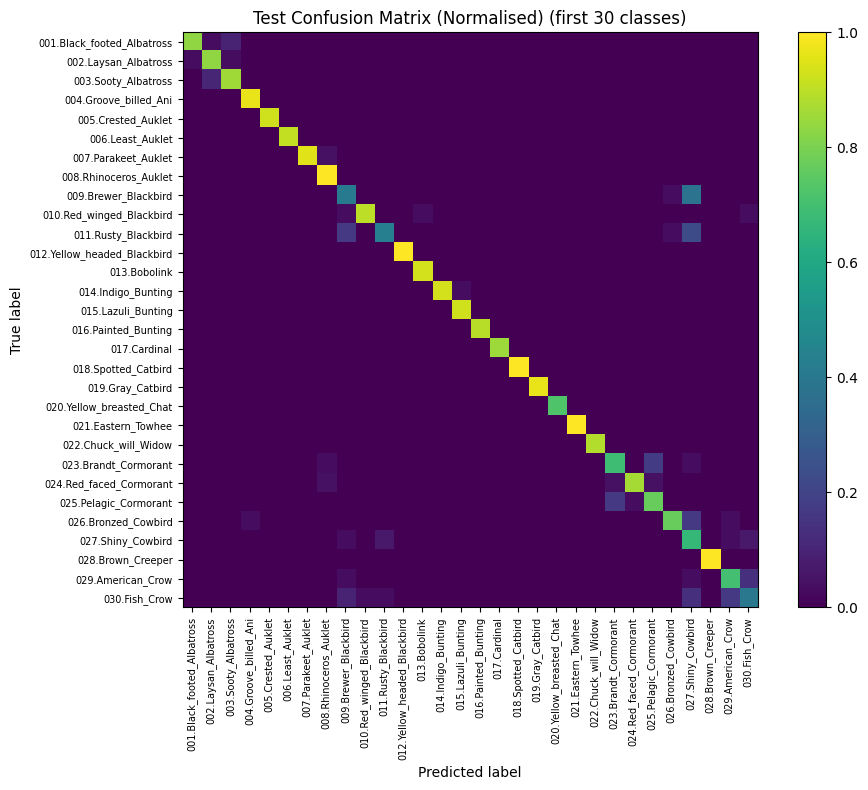

In [ ]:
# Plot Confusion Matrix

import numpy as np
import matplotlib.pyplot as plt

class_names_list = classes_txt.sort_values("class_id")["class_name"].tolist()

def plot_confusion_matrix(cm, class_names=None, max_classes_to_show=30, normalize=False, title="Confusion Matrix"):

    cm = cm.astype(np.float32)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True) + 1e-9
        cm = cm / row_sums

    C = cm.shape[0]
    n = min(C, max_classes_to_show)

    cm_small = cm[:n, :n]
    names_small = class_names[:n] if class_names is not None else [str(i) for i in range(n)]

    plt.figure(figsize=(10, 8))
    plt.imshow(cm_small, interpolation="nearest")
    plt.title(title + (f" (first {n} classes)" if C > n else ""))
    plt.colorbar()

    tick_marks = np.arange(n)
    plt.xticks(tick_marks, names_small, rotation=90, fontsize=7)
    plt.yticks(tick_marks, names_small, fontsize=7)

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(
    cm=test_cm,
    class_names=class_names_list,
    normalize=True,
    title="Test Confusion Matrix (Normalised)"
)

In [ ]:
# Load Saved Model Checkpoint from Google Drive

from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf

model_path = "/content/drive/MyDrive/cub_models/efficientnetb2_final.keras"
model = tf.keras.models.load_model(model_path, compile=False)

print("Model loaded successfully.")

# Load Saved Test Predictions (y_true and y_pred)

y_true_test = np.load("/content/drive/MyDrive/cub_models/y_true_test.npy")
y_pred_test = np.load("/content/drive/MyDrive/cub_models/y_pred_test.npy")



Loaded model.
Per-image predictions saved to: /content/drive/MyDrive/demo_predictions.csv

*** DEMO RESULTS (Flip-TTA) ***
Accuracy: 0.9148936170212766
Macro Precision: 0.31916492984719663
Macro Recall: 0.305513758272379
Macro F1: 0.31214396478140133
Confusion matrix shape: (15, 15)


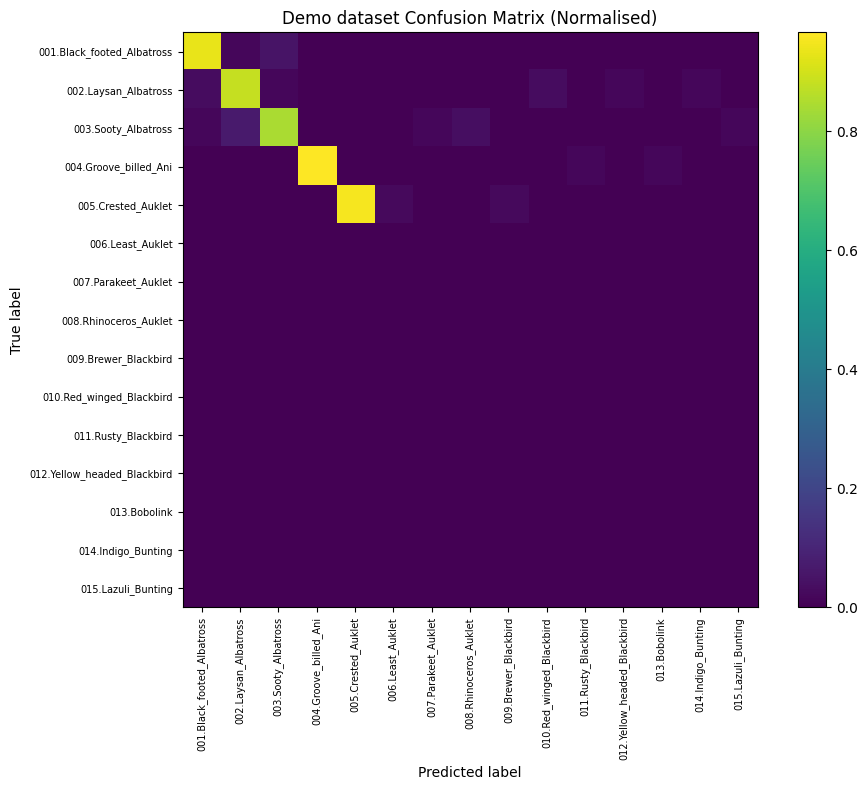

In [ ]:
# DEMO: Evaluate Folder-Based Test Structure (for DEMO purposes)

import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

IMG_SIZE = 260
NUM_CLASSES = 200
MODEL_PATH = "/content/drive/MyDrive/cub_models/efficientnetb2_final.keras"

preprocess = tf.keras.applications.efficientnet.preprocess_input

def load_and_preprocess_image(path):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_bytes, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = preprocess(img)
    return img

def flip_tta_probs(model, x_batch):
    p1 = model(x_batch, training=False)
    p2 = model(tf.image.flip_left_right(x_batch), training=False)
    return (p1 + p2) / 2.0

def demo_evaluate_test_folder(test_root):

    model = tf.keras.models.load_model(MODEL_PATH, compile=False)
    print("Loaded model.")

    image_paths = []
    y_true = []
    true_folder_names = []

    # Sort folders to keep class order consistent
    class_folders = sorted([f for f in os.listdir(test_root) if os.path.isdir(os.path.join(test_root, f))])

    # Map true class index (0..199)
    id_to_folder = {}
    folder_to_id = {}

    for folder in class_folders:
        class_id_str = folder.split(".")[0]
        class_id = int(class_id_str)

        # Convert to model index 0..199
        model_id = class_id - 1

        id_to_folder[model_id] = folder
        folder_to_id[folder] = model_id

    # Now collect images
    for folder in class_folders:
        class_path = os.path.join(test_root, folder)
        true_id = folder_to_id[folder]

        for file in os.listdir(class_path):
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                image_paths.append(os.path.join(class_path, file))
                y_true.append(true_id)
                true_folder_names.append(folder)

    y_true = np.array(y_true)

    # Build dataset
    ds = tf.data.Dataset.from_tensor_slices(image_paths)
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(32).prefetch(tf.data.AUTOTUNE)

    # Predict with TTA
    y_pred = []
    for xb in ds:
        probs = flip_tta_probs(model, xb).numpy()
        y_pred.extend(np.argmax(probs, axis=1))

    y_pred = np.array(y_pred)

    # Convert predicted IDs back to folder names
    pred_folder_names = [id_to_folder.get(int(i), f"UNKNOWN_{int(i)+1:03d}") for i in y_pred]

    # Create per-image predictions dataframe
    results_df = pd.DataFrame({
        "filepath": image_paths,
        "true_label": true_folder_names,
        "predicted_label": pred_folder_names
    })

    # Save CSV to Drive
    save_path = "/content/drive/MyDrive/demo_predictions.csv"
    results_df.to_csv(save_path, index=False)
    print("Per-image predictions saved to:", save_path)

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)

    print("\n*** DEMO RESULTS (Flip-TTA) ***")
    print("Accuracy:", acc)
    print("Macro Precision:", precision)
    print("Macro Recall:", recall)
    print("Macro F1:", f1)
    print("Confusion matrix shape:", cm.shape)

    return acc, precision, recall, f1, cm, results_df

test_root = "/content/drive/MyDrive/test"
acc, precision, recall, f1, cm, results_df = demo_evaluate_test_folder(test_root)

plot_confusion_matrix(
    cm,
    class_names=class_names_list,
    normalize=True,
    title="Demo dataset Confusion Matrix (Normalised)"
)

In [ ]:
results_df.head()

,filepath,true_label,predicted_label
0,/content/drive/MyDrive/test/001.Black_footed_A...,001.Black_footed_Albatross,001.Black_footed_Albatross
1,/content/drive/MyDrive/test/001.Black_footed_A...,001.Black_footed_Albatross,001.Black_footed_Albatross
2,/content/drive/MyDrive/test/001.Black_footed_A...,001.Black_footed_Albatross,001.Black_footed_Albatross
3,/content/drive/MyDrive/test/001.Black_footed_A...,001.Black_footed_Albatross,001.Black_footed_Albatross
4,/content/drive/MyDrive/test/001.Black_footed_A...,001.Black_footed_Albatross,001.Black_footed_Albatross


# Model 2: ImageNet Backbone with Custom head

In [ ]:
# MODEL 2 (Custom design): ImageNet backbone + Custom Head

import os
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# One-hot labels and CutMix/MixUp

def onehot_map(x, y):
    y = tf.one_hot(tf.cast(y, tf.int32), NUM_CLASSES)
    return x, y

# Convert base datasets to one-hot labels
train_ds_oh = train_ds.map(onehot_map, num_parallel_calls=AUTOTUNE)
val_ds_oh   = val_ds.map(onehot_map,   num_parallel_calls=AUTOTUNE).cache()
test_ds_oh  = test_ds.map(onehot_map,  num_parallel_calls=AUTOTUNE).cache()

# Augment probs and strengths
MIXUP_ALPHA  = 0.2
CUTMIX_ALPHA = 1.0
P_MIXUP  = 0.5
P_CUTMIX = 0.5

def sample_beta(size, alpha):
    gamma1 = tf.random.gamma([size], alpha, dtype=tf.float32)
    gamma2 = tf.random.gamma([size], alpha, dtype=tf.float32)
    return gamma1 / (gamma1 + gamma2)

def mixup_batch(x, y, alpha=MIXUP_ALPHA):
    B = tf.shape(x)[0]
    lam = sample_beta(B, alpha)
    lam_x = tf.cast(tf.reshape(lam, [B, 1, 1, 1]), x.dtype)
    lam_y = tf.cast(tf.reshape(lam, [B, 1]), y.dtype)

    idx = tf.random.shuffle(tf.range(B))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)

    x_out = x * lam_x + x2 * (tf.cast(1.0, x.dtype) - lam_x)
    y_out = y * lam_y + y2 * (tf.cast(1.0, y.dtype) - lam_y)
    return x_out, y_out

def cutmix_batch(x, y, alpha=CUTMIX_ALPHA):
    B = tf.shape(x)[0]
    H = tf.shape(x)[1]
    W = tf.shape(x)[2]

    idx = tf.random.shuffle(tf.range(B))
    x2 = tf.gather(x, idx)
    y2 = tf.gather(y, idx)

    lam = sample_beta(B, alpha)
    cut_rat = tf.sqrt(1.0 - lam)

    cut_w = tf.cast(tf.cast(W, tf.float32) * cut_rat, tf.int32)
    cut_h = tf.cast(tf.cast(H, tf.float32) * cut_rat, tf.int32)

    cx = tf.random.uniform([B], 0, W, dtype=tf.int32)
    cy = tf.random.uniform([B], 0, H, dtype=tf.int32)

    x1 = tf.clip_by_value(cx - cut_w // 2, 0, W)
    y1 = tf.clip_by_value(cy - cut_h // 2, 0, H)
    x2b = tf.clip_by_value(cx + cut_w // 2, 0, W)
    y2b = tf.clip_by_value(cy + cut_h // 2, 0, H)

    # mask [B,H,W,1]
    xs = tf.reshape(tf.range(W), [1, 1, W, 1])
    ys = tf.reshape(tf.range(H), [1, H, 1, 1])

    x1_ = tf.reshape(x1,  [B, 1, 1, 1])
    x2_ = tf.reshape(x2b, [B, 1, 1, 1])
    y1_ = tf.reshape(y1,  [B, 1, 1, 1])
    y2_ = tf.reshape(y2b, [B, 1, 1, 1])

    mask = tf.logical_and(tf.logical_and(xs >= x1_, xs < x2_),
                          tf.logical_and(ys >= y1_, ys < y2_))
    mask = tf.cast(mask, x.dtype)

    x_out = x * (tf.cast(1.0, x.dtype) - mask) + x2 * mask

    # adjust lambda by actual area
    area = tf.cast((x2b - x1) * (y2b - y1), tf.float32)
    total = tf.cast(H, tf.float32) * tf.cast(W, tf.float32)
    lam_adj = 1.0 - (area / (total + 1e-9))
    lam_adj_y = tf.cast(tf.reshape(lam_adj, [B, 1]), y.dtype)

    y_out = y * lam_adj_y + y2 * (tf.cast(1.0, y.dtype) - lam_adj_y)
    return x_out, y_out

def mix_augment(x, y):
    r = tf.random.uniform([], 0, 1)

    def do_mixup():
        return mixup_batch(x, y, MIXUP_ALPHA)

    def do_cutmix():
        return cutmix_batch(x, y, CUTMIX_ALPHA)

    def do_none():
        return x, y

    return tf.cond(
        r < P_MIXUP,
        do_mixup,
        lambda: tf.cond(r < (P_MIXUP + P_CUTMIX), do_cutmix, do_none)
    )

train_ds_mix2 = train_ds_oh.map(mix_augment, num_parallel_calls=AUTOTUNE)

# Smoke test
for xb, yb in train_ds_mix2.take(1):
    print("Model2 aug batch:", xb.shape, xb.dtype, "| labels:", yb.shape, yb.dtype,
          "| label sum ~1:", float(tf.reduce_mean(tf.reduce_sum(yb, axis=1))))

# Build Model 2: ImageNet backbone and custom head

def build_model2(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES, dropout=0.35):
    inputs = tf.keras.Input(shape=input_shape)

    backbone = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    backbone.trainable = False

    x = backbone(inputs, training=False)

    # Custom channel-attention gate
    s = tf.keras.layers.GlobalAveragePooling2D()(x)
    s = tf.keras.layers.Dense(256, activation="swish")(s)
    s = tf.keras.layers.Dense(x.shape[-1], activation="sigmoid")(s)
    s = tf.keras.layers.Reshape((1, 1, x.shape[-1]))(s)
    x = tf.keras.layers.Multiply()([x, s])

    # Pooling and custom MLP head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(dropout)(x)
    x = tf.keras.layers.Dense(512, activation="swish")(x)
    x = tf.keras.layers.Dropout(dropout)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", dtype="float32")(x)
    model = tf.keras.Model(inputs, outputs, name="model2_custom_birdnet")
    return model

model2 = build_model2()
model2.summary()

# Head training

os.makedirs("/content/checkpoints", exist_ok=True)
m2_ckpt = "/content/checkpoints/model2_custom_best.keras"

model2.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(m2_ckpt, monitor="val_accuracy", mode="max",
                                       save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max",
                                     patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                         patience=2, min_lr=1e-6, verbose=1),
]

history_m2 = model2.fit(
    train_ds_mix2,
    validation_data=val_ds_oh,
    epochs=40,
    callbacks=callbacks
)

print("Saved best Model 2 head-trained checkpoint at:", m2_ckpt)

# Fine-tuning + Cosine decay

model2 = tf.keras.models.load_model(m2_ckpt, compile=False)

N = 60
for layer in model2.layers:
    if isinstance(layer, tf.keras.Model) and "efficientnet" in layer.name.lower():
        for sublayer in layer.layers[:-N]:
            sublayer.trainable = False
        for sublayer in layer.layers[-N:]:
            if isinstance(sublayer, tf.keras.layers.BatchNormalization):
                sublayer.trainable = False
            else:
                sublayer.trainable = True

steps_per_epoch = int(np.ceil(len(train_df2) / BATCH_SIZE))
fine_tune_epochs = 15
total_steps = steps_per_epoch * fine_tune_epochs

ft_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=8e-6,
    decay_steps=total_steps,
    alpha=0.1
)

m2_ft_ckpt = "/content/checkpoints/model2_custom_finetuned_best.keras"

model2.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=ft_lr, weight_decay=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=["accuracy"]
)

callbacks_ft = [
    tf.keras.callbacks.ModelCheckpoint(m2_ft_ckpt, monitor="val_accuracy", mode="max",
                                       save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", mode="max",
                                     patience=5, restore_best_weights=True),
]

history_m2_ft = model2.fit(
    train_ds_mix2,
    validation_data=val_ds_oh,
    epochs=fine_tune_epochs,
    callbacks=callbacks_ft
)

print("Saved best Model 2 fine-tuned checkpoint at:", m2_ft_ckpt)

# Flip-TTA evaluation (VAL + TEST)

def predict_with_flip_tta(model, ds_oh):
    y_true = []
    y_pred = []
    for x, y in ds_oh:
        p1 = model(x, training=False)
        p2 = model(tf.image.flip_left_right(x), training=False)
        p = (p1 + p2) / 2.0
        y_pred.extend(tf.argmax(p, axis=1).numpy().tolist())
        y_true.extend(tf.argmax(y, axis=1).numpy().tolist())
    return np.array(y_true), np.array(y_pred)

def evaluate_classification(y_true, y_pred, num_classes=NUM_CLASSES):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    return acc, precision, recall, f1, cm

model2 = tf.keras.models.load_model(m2_ft_ckpt, compile=False)

y_true_val, y_pred_val = predict_with_flip_tta(model2, val_ds_oh)
val_acc, val_prec, val_rec, val_f1, val_cm = evaluate_classification(y_true_val, y_pred_val)

print("\nVAL (Model 2 Flip-TTA) accuracy:", val_acc)
print("VAL (Model 2 Flip-TTA) precision (macro):", val_prec)
print("VAL (Model 2 Flip-TTA) recall (macro):", val_rec)
print("VAL (Model 2 Flip-TTA) F1 (macro):", val_f1)
print("VAL confusion matrix shape:", val_cm.shape)

y_true_test, y_pred_test = predict_with_flip_tta(model2, test_ds_oh)
test_acc, test_prec, test_rec, test_f1, test_cm2 = evaluate_classification(y_true_test, y_pred_test)

print("\nTEST (Model 2 Flip-TTA) accuracy:", test_acc)
print("TEST (Model 2 Flip-TTA) precision (macro):", test_prec)
print("TEST (Model 2 Flip-TTA) recall (macro):", test_rec)
print("TEST (Model 2 Flip-TTA) F1 (macro):", test_f1)
print("TEST confusion matrix shape:", test_cm2.shape)


Model2 aug batch: (16, 260, 260, 3) <dtype: 'float16'> | labels: (16, 200) <dtype: 'float32'> | label sum ~1: 1.0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "model2_custom_birdnet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 260, 260,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 9, 9,      │  4,049,571 │ input_layer_1[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1280)      │    328,960 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1,      │          0 │ dense_1[0][0]     │
│                     │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 9, 9,      │          0 │ efficientnetb0[0… │
│                     │ 1280)             │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1280)      │      5,120 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │    655,872 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 512)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 200)       │    102,600 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,470,059 (20.87 MB)

 Trainable params: 1,417,928 (5.41 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

Epoch 1/40
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.0423 - loss: 5.5144
Epoch 1: val_accuracy improved from -inf to 0.46167, saving model to /content/checkpoints/model2_custom_best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 153s 409ms/step - accuracy: 0.0424 - loss: 5.5130 - val_accuracy: 0.4617 - val_loss: 3.6243 - learning_rate: 3.0000e-04
Epoch 2/40
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.2108 - loss: 4.0264
Epoch 2: val_accuracy improved from 0.46167 to 0.58167, saving model to /content/checkpoints/model2_custom_best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 126s 373ms/step - accuracy: 0.2109 - loss: 4.0261 - val_accuracy: 0.5817 - val_loss: 2.0619 - learning_rate: 3.0000e-04
Epoch 3/40
338/338 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.3426 - loss: 3.5193
Epoch 3: val_accuracy improved from 0.58167 to 0.66000, saving model to /content/checkpoints/model2_custom_best.keras
338/338 ━━━━━━━━━━━━━━━━━━━━ 127s 376ms/step - accuracy: 0.3426 - loss: 3.5192 - val_ac

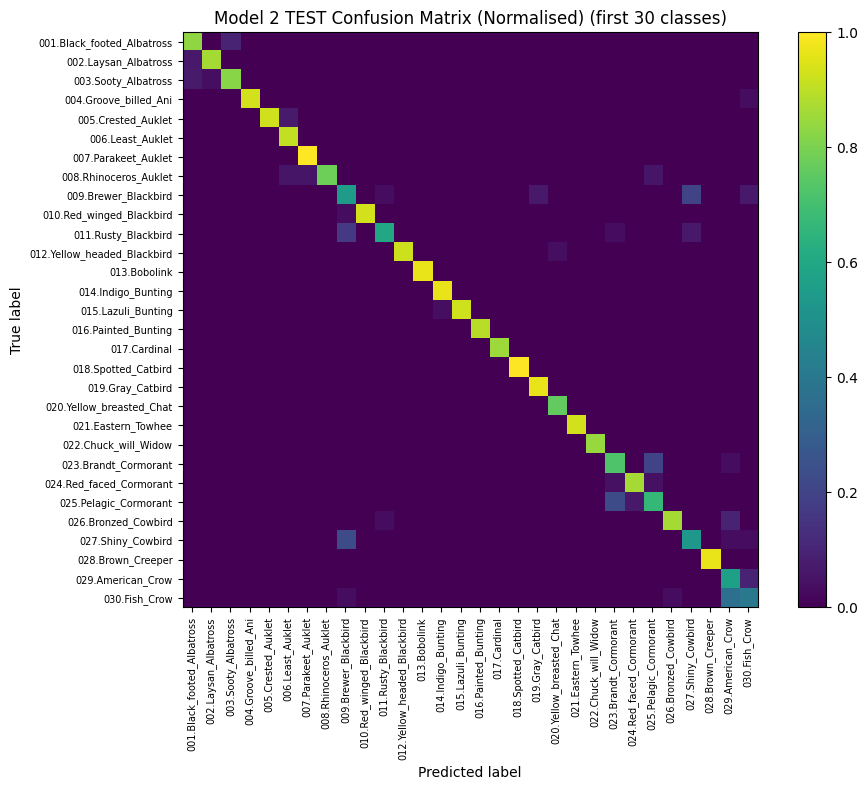

In [ ]:
# Plot TEST confusion matrix

import matplotlib.pyplot as plt

class_names_list = classes_txt.sort_values("class_id")["class_name"].tolist()

def plot_confusion_matrix(cm, class_names=None, max_classes_to_show=30, normalize=False, title="Confusion Matrix"):

    cm = cm.astype(np.float32)

    if normalize:
        row_sums = cm.sum(axis=1, keepdims=True) + 1e-9
        cm = cm / row_sums

    C = cm.shape[0]
    n = min(C, max_classes_to_show)

    cm_small = cm[:n, :n]
    names_small = class_names[:n] if class_names is not None else [str(i) for i in range(n)]

    plt.figure(figsize=(10, 8))
    plt.imshow(cm_small, interpolation="nearest")
    plt.title(title + (f" (first {n} classes)" if C > n else ""))
    plt.colorbar()

    tick_marks = np.arange(n)
    plt.xticks(tick_marks, names_small, rotation=90, fontsize=7)
    plt.yticks(tick_marks, names_small, fontsize=7)

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(
    cm=test_cm2,
    class_names=class_names_list,
    normalize=True,
    title="Model 2 TEST Confusion Matrix (Normalised)"
)
